In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler,LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    RFE,
    RFECV,
    SequentialFeatureSelector
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
!pip install ucimlrepo


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
ionosphere = fetch_ucirepo(id=52) 
  
# data (as pandas dataframes) 
x = ionosphere.data.features 
y = ionosphere.data.targets 
  
# metadata 
print(ionosphere.metadata) 
  
# variable information 
print(ionosphere.variables) 

{'uci_id': 52, 'name': 'Ionosphere', 'repository_url': 'https://archive.ics.uci.edu/dataset/52/ionosphere', 'data_url': 'https://archive.ics.uci.edu/static/public/52/data.csv', 'abstract': 'Classification of radar returns from the ionosphere', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 351, 'num_features': 34, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Sun Jan 01 1989', 'dataset_doi': '10.24432/C5W01B', 'creators': ['V. Sigillito', 'S. Wing', 'L. Hutton', 'K. Baker'], 'intro_paper': None, 'additional_info': {'summary': 'This radar data was collected by a system in Goose Bay, Labrador.  This system consists of a phased array of 16 high-frequency antennas with a total transmitted power on the order of 6.4 kilowatts.  See the paper for more details.  

In [5]:
x.shape

(351, 34)

In [6]:
y.shape

(351, 1)

In [7]:
df=pd.DataFrame(x)

In [8]:
df['Target']=y

In [9]:
df.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34,Target
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Attribute1   351 non-null    int64  
 1   Attribute2   351 non-null    int64  
 2   Attribute3   351 non-null    float64
 3   Attribute4   351 non-null    float64
 4   Attribute5   351 non-null    float64
 5   Attribute6   351 non-null    float64
 6   Attribute7   351 non-null    float64
 7   Attribute8   351 non-null    float64
 8   Attribute9   351 non-null    float64
 9   Attribute10  351 non-null    float64
 10  Attribute11  351 non-null    float64
 11  Attribute12  351 non-null    float64
 12  Attribute13  351 non-null    float64
 13  Attribute14  351 non-null    float64
 14  Attribute15  351 non-null    float64
 15  Attribute16  351 non-null    float64
 16  Attribute17  351 non-null    float64
 17  Attribute18  351 non-null    float64
 18  Attribute19  351 non-null    float64
 19  Attribute20  351 no

In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df = df.drop_duplicates()

In [13]:
df['Target'].value_counts()

Target
g    225
b    125
Name: count, dtype: int64

<Axes: xlabel='Target', ylabel='count'>

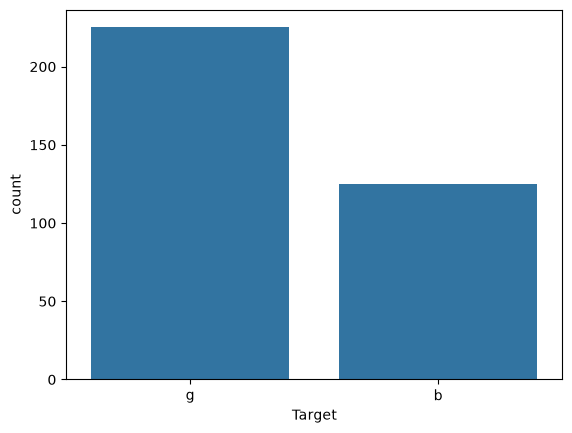

In [14]:
sns.countplot(data=df,x='Target')

In [15]:
encoder=LabelEncoder()
y_encoded=encoder.fit_transform(y)
print(f"Classes: {encoder.classes_}")
print(f"Encoded values: {np.unique(y_encoded)}")

Classes: ['b' 'g']
Encoded values: [0 1]


c:\Users\ahmed rodwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:
X_train,X_test,y_train,y_test=train_test_split(x,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)

In [18]:
X_train.shape

(280, 34)

In [19]:
X_test.shape

(71, 34)

In [20]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
cv_model=LogisticRegression(max_iter=2000,random_state=42)

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_scores=cross_val_score(cv_model,X_train_scaled,y_train,cv=cv,scoring='accuracy')

In [22]:
print("Training Accuracy for each fold")
print(cv_scores)

Training Accuracy for each fold
[0.875      0.91071429 0.85714286 0.91071429 0.83928571]


In [23]:
print("Average Train Accuracy")
print(cv_scores.mean())

Average Train Accuracy
0.8785714285714284


In [24]:
baseline_model=LogisticRegression(max_iter=2000,random_state=42)
baseline_model.fit(X_train_scaled,y_train)
baseline_predictions=baseline_model.predict(X_test_scaled)

In [25]:
baseline_accuracy=accuracy_score(y_test,baseline_predictions)
baseline_precision=precision_score(y_test,baseline_predictions)
baseline_recall=recall_score(y_test,baseline_predictions)
baseline_f1_score=f1_score(y_test,baseline_predictions)

print(f"Baseline Accuracy: {baseline_accuracy*100:.2f}%")
print(f"Baseline Precision: {baseline_precision:.2f}")
print(f"Baseline Recall: {baseline_recall:.2f}")
print(f"Baseline F1-Score: {baseline_f1_score:.2f}")

Baseline Accuracy: 92.96%
Baseline Precision: 0.92
Baseline Recall: 0.98
Baseline F1-Score: 0.95


In [26]:
print(classification_report(y_test,baseline_predictions))

              precision    recall  f1-score   support

           0       0.95      0.84      0.89        25
           1       0.92      0.98      0.95        46

    accuracy                           0.93        71
   macro avg       0.94      0.91      0.92        71
weighted avg       0.93      0.93      0.93        71



In [28]:
rfe_model=LogisticRegression(max_iter=2000,random_state=42)
rfe=RFE(estimator=rfe_model,
        n_features_to_select=15,
        step=1
        )
rfe.fit(X_train_scaled,y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",15
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LogisticRegression,LogisticRegre...ndom_state=42)
n_features_ n_features_: intThe number of selected features.,int64,np.int64(15)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,34
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](34,)","[ 1,20, 1,...,11, 7, 1]"


In [29]:
rfe.support_

array([ True, False,  True, False,  True,  True, False,  True, False,
       False,  True, False, False,  True,  True, False, False,  True,
       False, False, False,  True, False, False,  True, False,  True,
       False,  True,  True, False, False, False,  True])

In [30]:
rfe_selected_features=X_train.columns[rfe.support_]

In [31]:
len(list(rfe_selected_features))

15

In [32]:
X_train_rfe=rfe.transform(X_train_scaled)
X_test_rfe=rfe.transform(X_test_scaled)

In [33]:
rfe_final_model=LogisticRegression(max_iter=2000,random_state=42)
rfe_final_model.fit(X_train_rfe,y_train)
rfe_predictions=rfe_final_model.predict(X_test_rfe)

In [34]:
rfe_accuracy=accuracy_score(y_test,rfe_predictions)
rfe_precision=precision_score(y_test,rfe_predictions)
rfe_recall=recall_score(y_test,rfe_predictions)
rfe_f1_score=f1_score(y_test,rfe_predictions)

print(f"RFE Accuracy: {rfe_accuracy*100:.2f}%")
print(f"RFE Precision: {rfe_precision:.2f}")
print(f"RFE Recall: {rfe_recall:.2f}")
print(f"RFE F1-Score: {rfe_f1_score:.2f}")

RFE Accuracy: 91.55%
RFE Precision: 0.92
RFE Recall: 0.96
RFE F1-Score: 0.94
